In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split 
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler, MaxAbsScaler, PowerTransformer, FunctionTransformer
from sklearn.linear_model import LinearRegression
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import cross_val_score
from sklearn.feature_selection import VarianceThreshold
from sklearn.ensemble import BaggingRegressor,VotingRegressor, RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
import  cloudpickle
import mlflow
from dotenv import load_dotenv
import os

In [2]:
db = pd.read_csv("data/train.csv")
db.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [3]:
db["SalePrice"].max()

np.int64(755000)

In [4]:
info = db.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

# Creating Functions for managing various custom operations in this notebook

## Creating a function for identifying numerical and categorical columns to better manage features

In [5]:
def automate_colms(cols):
    """This function takes in a list of columns and returns a list of categorical and numerical columns"""
    cata_cols = []
    num_cols = []
    for i in cols:
        if db[i].dtype == "object" or db[i].dtype == "category":
            cata_cols.append(i)
        elif db[i].dtype in ["int64", "float64", "int32", "float32"]:
             if i not in ['Id', 'SalePrice']:
                num_cols.append(i)
        else:
            cata_cols.append(i)
    return cata_cols, num_cols

# Handling Null Values

## Identifying null columns

In [6]:
def print_null(db):
    """This function takes a dataframe and returs a list of columns which are required to be dropped since they have more than 90% null values and a list of other columns with null values"""
    drop_cols = []
    null_cols = []
    for i in db.columns:
        if db[i].isna().sum() > 0:
            percentage = round((db[i].isna().sum()/db[i].count())* 100, 2)
            if percentage >= 10:
                drop_cols.append(i)
                print(f"{i}: {percentage}")
            else:
                null_cols.append(i)
                print(f"{i}: {percentage}")
    return drop_cols, null_cols

drop_cols, null_cols = print_null(db)

LotFrontage: 21.57
Alley: 1504.4
MasVnrType: 148.3
MasVnrArea: 0.55
BsmtQual: 2.6
BsmtCond: 2.6
BsmtExposure: 2.67
BsmtFinType1: 2.6
BsmtFinType2: 2.67
Electrical: 0.07
FireplaceQu: 89.61
GarageType: 5.87
GarageYrBlt: 5.87
GarageFinish: 5.87
GarageQual: 5.87
GarageCond: 5.87
PoolQC: 20757.14
Fence: 419.57
MiscFeature: 2603.7


## Dropping features which have null values more than 10% of total feature values

In [7]:
db = db.drop(columns=drop_cols, axis=1)

## Printing rest columns with null values 

In [8]:
drop_cols, null_cols = print_null(db)

MasVnrArea: 0.55
BsmtQual: 2.6
BsmtCond: 2.6
BsmtExposure: 2.67
BsmtFinType1: 2.6
BsmtFinType2: 2.67
Electrical: 0.07
GarageType: 5.87
GarageYrBlt: 5.87
GarageFinish: 5.87
GarageQual: 5.87
GarageCond: 5.87


## Identifying the type of features with null values ie: numerical or categorical

In [9]:
null_cata, null_num = automate_colms(null_cols)
print(f"Null Catagorical Columns: {null_cata}, Null Numerical Columns: {null_num}")

Null Catagorical Columns: ['BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Electrical', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond'], Null Numerical Columns: ['MasVnrArea', 'GarageYrBlt']


## Imputing the values to handle null values for both categorical and numerical null columns

In [10]:
for i in null_cata:
    db[i].fillna(db[i].mode()[0], inplace = True)

for i in null_num:
    db[i].fillna(db[i].median(), inplace = True)

C:\Users\apoor\AppData\Local\Temp\ipykernel_16156\3223594109.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  db[i].fillna(db[i].mode()[0], inplace = True)
C:\Users\apoor\AppData\Local\Temp\ipykernel_16156\3223594109.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For exampl

## Checking the updated columns

In [11]:
db.head()

,Id,MSSubClass,MSZoning,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,...,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,8450,Pave,Reg,Lvl,AllPub,Inside,Gtl,...,0,0,0,0,0,2,2008,WD,Normal,208500
1,2,20,RL,9600,Pave,Reg,Lvl,AllPub,FR2,Gtl,...,0,0,0,0,0,5,2007,WD,Normal,181500
2,3,60,RL,11250,Pave,IR1,Lvl,AllPub,Inside,Gtl,...,0,0,0,0,0,9,2008,WD,Normal,223500
3,4,70,RL,9550,Pave,IR1,Lvl,AllPub,Corner,Gtl,...,272,0,0,0,0,2,2006,WD,Abnorml,140000
4,5,60,RL,14260,Pave,IR1,Lvl,AllPub,FR2,Gtl,...,0,0,0,0,0,12,2008,WD,Normal,250000


## Basemodel using Linear Regression

In [12]:
numerical_columns = db.select_dtypes(include=[np.number]).columns
numerical_columns = numerical_columns[1:-1]
categorical_columns = db.select_dtypes(include=["object"]).columns

### Encoding categorical features using One Hot Encoding

In [13]:

x = db.iloc[:,1:-1]
y = db.iloc[:,-1]

x = pd.get_dummies(x, columns=categorical_columns, drop_first=True)


In [14]:
x_train, x_test, y_train, y_test = train_test_split(x,y,random_state=42)

lr = LinearRegression()
lr.fit(x_train,y_train)
y_pred = lr.predict(x_test)

score = round(np.sqrt(mean_squared_error(y_test,y_pred)),2)
r2score = round(r2_score(y_test,y_pred),2)

print(f"Root Mean Squared Error for basemodel: {score}")
print(f"R2 Score for basemodel: {r2score}")

result_basemodel = {"rmse": int(score), "R2": r2score}

Root Mean Squared Error for basemodel: 46685.57
R2 Score for basemodel: 0.69


### Saving the templte for the user to be able to download and format data for prediction

In [15]:
test_db = pd.DataFrame([],columns=x_train.columns)
test_db.to_csv("data/basetemplate.csv", index=False)

### Logging Model on Mlflow

In [16]:
# mlflow.set_tracking_uri("http://127.0.0.1:5000")
# mlflow.set_experiment("Base Model")


# with mlflow.start_run():
#     mlflow.log_metrics({
#         "rmse": score,
#         "R2": r2score
#     })
#     mlflow.sklearn.log_model(sk_model=lr, name="Linear Regression Base Model", registered_model_name="Linear Regression Base Model")

In [17]:
with open("models/basemodel.cloudpickle", "wb") as f:
    cloudpickle.dump(lr,f)

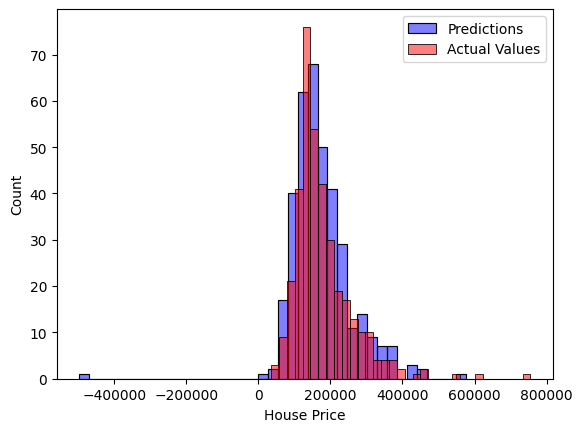

In [18]:
plt.Figure()
sns.histplot(y_pred, color='blue', alpha = 0.5, label = "Predictions")
sns.histplot(y_test, color='red', alpha = 0.5, label = "Actual Values")
plt.xlabel("House Price")
plt.legend()
plt.show()

# Applying various normalization and standardization techniques to identify which technique performs best for Linear Regression

## Identifying numerical and categorical columns

In [19]:
normal_models = {}

x = db.iloc[:, 1:-1]
x = pd.get_dummies(x, columns=categorical_columns, drop_first=True)
x.columns = x.columns.astype(str)
y = db.iloc[:,-1]

x_train, x_test, y_train, y_test = train_test_split(x,y,random_state=42)

In [20]:
cols = x.columns
cols

Index(['MSSubClass', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt',
       'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF',
       ...
       'SaleType_ConLI', 'SaleType_ConLw', 'SaleType_New', 'SaleType_Oth',
       'SaleType_WD', 'SaleCondition_AdjLand', 'SaleCondition_Alloca',
       'SaleCondition_Family', 'SaleCondition_Normal',
       'SaleCondition_Partial'],
      dtype='object', length=228)

In [21]:
def predict_and_find_error(xtrain, ytrain,xtest,ytest, name):
    lr = LinearRegression()
    lr.fit(xtrain,ytrain)
    
    ypred = lr.predict(xtest)
    score = round(np.sqrt(mean_squared_error(ytest,ypred)),2)
    print(f"Root Mean Squared Error for {name}: {score}")

In [22]:
standard = StandardScaler()
minMax = MinMaxScaler()
robust = RobustScaler()
maxabs = MaxAbsScaler()
power = PowerTransformer()

x_train, x_test, y_train, y_test = train_test_split(x,y,random_state=42)
x_train = standard.fit_transform(x_train)
x_test = standard.transform(x_test)
predict_and_find_error(x_train,y_train,x_test,y_test, "StandardSclaer")

# x_train, x_test, y_train, y_test = train_test_split(x,y,random_state=42)
# x_train = minMax.fit_transform(x_train)
# x_test = minMax.transform(x_test)
# predict_and_find_error(x_train,y_train,x_test,y_test, "MinMaxScaler")

# x_train, x_test, y_train, y_test = train_test_split(x,y,random_state=42)
# x_train = robust.fit_transform(x_train)
# x_test = robust.transform(x_test)
# predict_and_find_error(x_train,y_train,x_test,y_test, "RobustScaler")

# x_train, x_test, y_train, y_test = train_test_split(x,y,random_state=42)
# x_train = maxabs.fit_transform(x_train)
# x_test = maxabs.transform(x_test)
# predict_and_find_error(x_train,y_train,x_test,y_test, "MaxAbsScaler")


# x_train, x_test, y_train, y_test = train_test_split(x,y,random_state=42)
x_train = power.fit_transform(x_train)
x_test = power.transform(x_test)
predict_and_find_error(x_train,y_train,x_test,y_test, "PowerTransformer")

Root Mean Squared Error for StandardSclaer: 46685.57
Root Mean Squared Error for PowerTransformer: 39946.53


## Observation: Standard Scaler when paired along with power transformer gives the best results with Linear Regression

# Final Model

In [23]:
x = db.iloc[:, 1:-1]
col_cata, col_nums = automate_colms(x.columns) # Identifying numerical columns for log transformation
x = pd.get_dummies(x, columns=categorical_columns, drop_first=True)
x.columns = x.columns.astype(str)
y = db.iloc[:,-1]

x_train, x_test, y_train, y_test = train_test_split(x,y,random_state=42)

x_train = standard.fit_transform(x_train)
x_test = standard.transform(x_test)

x_train = pd.DataFrame(power.fit_transform(x_train), columns=x.columns)
x_test = pd.DataFrame(power.transform(x_test), columns=x.columns)


## Handling outliers

In [24]:
# Applying IQR based capping

def cap(col):

    df = pd.DataFrame(col)

    q1 = df.quantile(0.25)
    q2 = df.quantile(0.75)
    iqr = q2-q1
    upper = q2 + 1.5*iqr
    lower = q1 - 1.5*iqr
    df = np.where(df>upper,
                  upper,
                  np.where(df<lower,
                           lower,
                           df)) 
    return df

cap_outliers = FunctionTransformer(cap,inverse_func=np.exp,validate= True)

column_outlier = ColumnTransformer(transformers=[("coloutlier", cap_outliers,col_nums)], remainder="passthrough")
x_train = pd.DataFrame(column_outlier.fit_transform(x_train), columns=x.columns)
x_test = pd.DataFrame(column_outlier.transform(x_test), columns=x.columns)

c:\Users\apoor\projects\housingrates\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but FunctionTransformer was fitted with feature names
  warnings.warn(
c:\Users\apoor\projects\housingrates\.venv\Lib\site-packages\sklearn\preprocessing\_function_transformer.py:210: UserWarning: The provided functions are not strictly inverse of each other. If you are sure you want to proceed regardless, set 'check_inverse=False'.
  warnings.warn(


## Removing Duplicate Columns

In [25]:
def duplicate_columns(db):
    column_summary = {}
    visited_column = {}

    for column in db.columns:
        current_column = db[column]
        try:
            binary_column = current_column.values.tobytes()
        except:
            binary_column = current_column.to_string().encode()

        if binary_column in visited_column:
            if visited_column[binary_column] in column_summary:
                column_summary[visited_column[binary_column]].append(column)
            else:
                column_summary[visited_column[binary_column]] = [column]
        else:
            visited_column[binary_column] = column
    
    result = column_summary
    return result

col_summary = duplicate_columns(x_train)
print(col_summary)

{'Condition2_PosA': ['Condition2_RRNn', 'RoofMatl_Membran', 'Electrical_Mix'], 'Exterior1st_CBlock': ['Exterior2nd_CBlock']}


In [26]:
x_train[['Condition2_RRNn', 'RoofMatl_Membran', 'Electrical_Mix',"Condition2_PosA", "Exterior1st_CBlock", 'Exterior2nd_CBlock']]

,Condition2_RRNn,RoofMatl_Membran,Electrical_Mix,Condition2_PosA,Exterior1st_CBlock,Exterior2nd_CBlock
0,0.0,0.0,0.0,0.0,-0.030234,-0.030234
1,0.0,0.0,0.0,0.0,-0.030234,-0.030234
2,0.0,0.0,0.0,0.0,-0.030234,-0.030234
3,0.0,0.0,0.0,0.0,-0.030234,-0.030234
4,0.0,0.0,0.0,0.0,-0.030234,-0.030234
...,...,...,...,...,...,...
1090,0.0,0.0,0.0,0.0,-0.030234,-0.030234
1091,0.0,0.0,0.0,0.0,-0.030234,-0.030234
1092,0.0,0.0,0.0,0.0,-0.030234,-0.030234
1093,0.0,0.0,0.0,0.0,-0.030234,-0.030234


In [27]:
for items in col_summary.values():
    x_train.drop(columns=items, inplace=True)
    x_test.drop(columns=items, inplace=True)

In [28]:
variance = x_train.var()
print(np.min(variance))

0.0


## Applying feature selection 

## Applying Coorelation method for reducing features

In [29]:

def corrfeatures(corr_matrix):
    columns = corr_matrix.columns
    remove_features = []

    for i in range(len(columns)):
        for j in range(i+1,len(columns)):
            if corr_matrix.iloc[i,j] > 0.75:
                remove_features.append(columns[j])
    
    return remove_features


corr_matrix = x_train.corr()
features_to_remove = corrfeatures(corr_matrix)
print(features_to_remove)

x_train = x_train.drop(columns=features_to_remove)
x_test = x_test.drop(columns=features_to_remove)

['GarageYrBlt', '1stFlrSF', 'HouseStyle_2Story', 'TotRmsAbvGrd', 'GarageArea', 'Neighborhood_Somerst', 'Exterior2nd_CmentBd', 'Exterior2nd_HdBoard', 'Exterior2nd_MetalSd', 'Exterior2nd_VinylSd', 'Exterior2nd_Wd Sdng', 'SaleCondition_Partial']


## Applying Variance Threshold Method 

In [30]:
vthreshold = VarianceThreshold(threshold=0.05)

vthreshold.fit_transform(x_train)
cols = x_train.columns[vthreshold.get_support()]

x_train = vthreshold.fit_transform(x_train)
x_test = vthreshold.transform(x_test)

x_train = pd.DataFrame(x_train, columns=cols)
x_test = pd.DataFrame(x_test, columns=cols)

In [31]:
corr = x_train.corr(method='pearson')
corr

,MSSubClass,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtUnfSF,TotalBsmtSF,...,SaleType_ConLD,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal
MSSubClass,1.000000,-0.326323,0.094716,-0.044724,0.007394,0.023387,-0.008902,-0.118091,-0.121540,-0.305929,...,0.070347,0.000848,0.041873,-0.067997,0.031097,0.039836,0.035493,0.062525,0.009284,0.023310
LotArea,-0.326323,1.000000,0.200652,-0.000575,0.037967,0.041506,0.146205,0.185722,0.062419,0.349117,...,-0.003537,0.018253,-0.019224,0.074145,-0.014328,-0.041057,-0.024397,0.019587,0.009892,-0.043672
OverallQual,0.094716,0.200652,1.000000,-0.104967,0.616171,0.550798,0.408556,0.126261,0.309017,0.515488,...,-0.025576,-0.044087,0.017441,0.316877,-0.049340,-0.217739,-0.050760,-0.016287,-0.017310,-0.145275
OverallCond,-0.044724,-0.000575,-0.104967,1.000000,-0.396721,0.010632,-0.156236,0.002441,-0.134876,-0.185488,...,-0.055109,0.018458,0.016395,-0.155227,-0.065361,0.151532,-0.040886,0.004299,-0.045610,0.167359
YearBuilt,0.007394,0.037967,0.616171,-0.396721,1.000000,0.655966,0.379078,0.155193,0.184860,0.423408,...,-0.044652,-0.037096,-0.006841,0.395731,0.000876,-0.268914,-0.052530,-0.012323,-0.033295,-0.195275
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
SaleType_WD,0.039836,-0.041057,-0.217739,0.151532,-0.268914,-0.221271,-0.140270,-0.014545,-0.130050,-0.190118,...,-0.209494,-0.136895,-0.158145,-0.776844,-0.078964,1.000000,0.023184,0.025932,0.025960,0.654738
SaleCondition_AdjLand,0.035493,-0.024397,-0.050760,-0.040886,-0.052530,-0.046569,-0.015012,-0.019846,-0.044831,-0.069977,...,-0.004857,-0.003174,-0.003666,-0.018010,-0.001831,0.023184,1.000000,-0.004101,-0.007604,-0.133426
SaleCondition_Alloca,0.062525,0.019587,-0.016287,0.004299,-0.012323,-0.021401,-0.053406,-0.024787,-0.057990,-0.079160,...,-0.005433,-0.003550,-0.004101,-0.020145,-0.002048,0.025932,-0.004101,1.000000,-0.008505,-0.149243
SaleCondition_Family,0.009284,0.009892,-0.017310,-0.045610,-0.033295,-0.047730,-0.003171,-0.016385,0.015477,0.027548,...,-0.010073,-0.006582,-0.007604,-0.037352,-0.003797,0.025960,-0.007604,-0.008505,1.000000,-0.276718


In [32]:
test_db = pd.DataFrame([],columns=x_train.columns)
test_db.to_csv("data/template.csv", index=False)

## Training model

In [33]:
lr = LinearRegression()

lr.fit(x_train,y_train)

y_pred = lr.predict(x_test)

score = round(np.sqrt(mean_squared_error(y_test,y_pred)),2)
cvscore = cross_val_score(lr,x_train,y_train,cv=5,scoring="r2")
r2score = r2_score(y_test,y_pred)

print(f"Cross Val Score (R2 Score): {round(np.average(cvscore),2)}")
print(f"R2 Score: {round(r2score,2)}")
print(f"RMSE for final Model: {score}")

Cross Val Score (R2 Score): 0.78
R2 Score: 0.83
RMSE for final Model: 34980.45


In [34]:
# mlflow.set_tracking_uri("http://127.0.0.1:5000")
# mlflow.set_experiment("Linear Regression")

# with mlflow.start_run():
#     mlflow.log_metrics({
#         "Cross Val Score": round(np.average(cvscore),2),
#         "Root Mean Squared Error": score,
#         "R2 Score": round(r2score,2)
#     })
#     mlflow.sklearn.log_model(sk_model=lr, name="Linear Regression", registered_model_name="Linear Regression")

In [35]:
with open("models/lrmodel.cloudpickle", "wb") as f:
    cloudpickle.dump(lr,f)

## Using Ensemble Techniques

## Bagging Regressor

In [36]:
bag = BaggingRegressor(random_state=1)

bag.fit(x_train,y_train)

y_pred = bag.predict(x_test)

r2score = round(r2_score(y_test,y_pred),2)
rmse = round(np.sqrt(mean_squared_error(y_test,y_pred)),2)
cvscore = cross_val_score(bag,x_train,y_train,cv=5,scoring="r2")

print(f"R2 Score after applying bagging regressor: {r2score}")
print(f"RMSE after applying bagging regressor: {rmse}")
print(f"Cross Validation Score after applying bagging regressor: {round(np.average(cvscore),2)}")

R2 Score after applying bagging regressor: 0.9
RMSE after applying bagging regressor: 26240.55
Cross Validation Score after applying bagging regressor: 0.79


In [37]:
# mlflow.set_tracking_uri("http://127.0.0.1:5000")
# mlflow.set_experiment("Bagging")

# with mlflow.start_run():
#     mlflow.log_metrics({
#         "Cross Val Score": round(np.average(cvscore),2),
#         "Root Mean Squared Error": score,
#         "R2 Score": round(r2score,2)
#     })
#     mlflow.log_param("random_state",1)
#     mlflow.sklearn.log_model(sk_model=bag, name="Bagging Regressor", registered_model_name="Bagging Regressor")

In [38]:
with open("models/baggingmodel.cloudpickle", "wb") as f:
    cloudpickle.dump(bag,f)

## Using Voting Regressor

In [39]:
lr = LinearRegression()
dtr = RandomForestRegressor()
knnr = KNeighborsRegressor(n_neighbors=5)
estimators = [("lr",lr),("dtr",dtr),("knn",knnr)]

for i in estimators:
    score = cross_val_score(i[1],x_test,y_test,scoring="r2")
    print(f"Cross Val Score for {i[0]}: {round(np.average(score),2)}")

Cross Val Score for lr: 0.64
Cross Val Score for dtr: 0.83
Cross Val Score for knn: 0.68


In [40]:
voting = VotingRegressor(estimators=estimators, weights=[1,2,1])

score = cross_val_score(voting,x_test,y_test,scoring="r2", cv=10)
print(f"Cross Val Score for Voting Ensemble: {round(np.average(score),2)}")

voting.fit(x_train,y_train)
y_pred = voting.predict(x_test)

r2score = round(r2_score(y_test,y_pred),2)
rmse = round(np.sqrt(mean_squared_error(y_test,y_pred)),2)

print(f"R2 Score after applying Voting ensemble: {r2score}")
print(f"RMSE after applying Voting ensemble: {rmse}")

Cross Val Score for Voting Ensemble: 0.85
R2 Score after applying Voting ensemble: 0.89
RMSE after applying Voting ensemble: 27983.37


In [41]:
# mlflow.set_tracking_uri("http://127.0.0.1:5000")
# mlflow.set_experiment("Voting")

# with mlflow.start_run():
#     mlflow.log_metrics({
#         "Cross Val Score": round(np.average(score),2),
#         "Root Mean Squared Error": rmse,
#         "R2 Score": r2score
#     })
#     mlflow.log_params({"estimators":str(estimators), "weights": str([1,2,1])})
    
#     mlflow.sklearn.log_model(sk_model=voting, name="Voting Ensemble", registered_model_name="Voting Ensemble")

In [42]:
with open("models/votingmodel.cloudpickle", "wb") as f:
    cloudpickle.dump(voting,f)

## Experimentation with dirrerent weights

In [43]:
# for i in range(1,4):
#     for j in range(1,4):
#         for k in range(1,4):
#             voting = VotingRegressor(estimators=estimators,weights=[i,j,k])
#             score = cross_val_score(voting,x_test,y_test,scoring="r2")
#             print("scoring weight for lr:{}, dtr:{}, knnr:{}   =".format(i,j,k),round(np.average(score),2))

## Applying Gradient Boosting Ensemble

In [44]:
gb = GradientBoostingRegressor(n_estimators=100)

gb.fit(x_train,y_train)

y_pred = gb.predict(x_test)
score = cross_val_score(gb,x_train,y_train,cv=10)
r2score = round(r2_score(y_test,y_pred),2)
rmse = round(np.sqrt(mean_squared_error(y_test,y_pred)),2)


print(f"Cross Val Score for Voting Ensemble: {round(np.average(score),2)}")
print(f"R2 Score after applying Voting ensemble: {r2score}")
print(f"RMSE after applying Voting ensemble: {rmse}")

Cross Val Score for Voting Ensemble: 0.85
R2 Score after applying Voting ensemble: 0.9
RMSE after applying Voting ensemble: 26277.26


In [45]:
# mlflow.set_tracking_uri("http://127.0.0.1:5000")
# mlflow.set_experiment("Boosting")

# with mlflow.start_run():
#     mlflow.log_metrics({
#         "Cross Val Score": round(np.average(score),2),
#         "Root Mean Squared Error": rmse,
#         "R2 Score": r2score
#     })
#     mlflow.log_param("n_estimators",100)
    
#     mlflow.sklearn.log_model(sk_model=gb, name="Gradient Boosting", registered_model_name="Gradient Boosting")

In [46]:
with open("models/boostingmodel.cloudpickle", "wb") as f:
    cloudpickle.dump(gb,f)

## saving the metrics of models

In [48]:
from mlflow.client import MlflowClient

run_dict = {}

client = MlflowClient()

experiments = client.search_experiments()

exp_ids = [exp.experiment_id for exp in experiments]
exp_ids = exp_ids[:-1]

try: 
    runs = client.search_runs(experiment_ids=exp_ids,max_results=100, order_by=["attributes.start_time DESC"])
    print("Successfully loaded runs data")
except Exception as e:
   print(f"Not able to get the runs data: {e}")

for run in runs[0:5]:
   run_dict[run.info.experiment_id] = {"metrics": run.data.metrics, "params": run.data.params}

print(run_dict)

with open("models/run_dict.cloudpickle", "wb") as f:
    cloudpickle.dump(run_dict,f)



Successfully loaded runs data
{'428448064423756712': {'metrics': {'Cross Val Score': 0.85, 'R2 Score': 0.9, 'Root Mean Squared Error': 26275.01}, 'params': {'n_estimators': '100'}}, '374848408681755308': {'metrics': {'Cross Val Score': 0.85, 'R2 Score': 0.89, 'Root Mean Squared Error': 28247.81}, 'params': {'estimators': "[('lr', LinearRegression()), ('dtr', RandomForestRegressor()), ('knn', KNeighborsRegressor())]", 'weights': '[1, 2, 1]'}}, '361855249608578602': {'metrics': {'Cross Val Score': 0.79, 'R2 Score': 0.9, 'Root Mean Squared Error': 34980.45}, 'params': {'random_state': '1'}}, '495584249720982550': {'metrics': {'Cross Val Score': 0.78, 'R2 Score': 0.83, 'Root Mean Squared Error': 34980.45}, 'params': {}}, '944212936157275241': {'metrics': {'R2': 0.69, 'rmse': 46685.57}, 'params': {}}}


## Residue Analysis

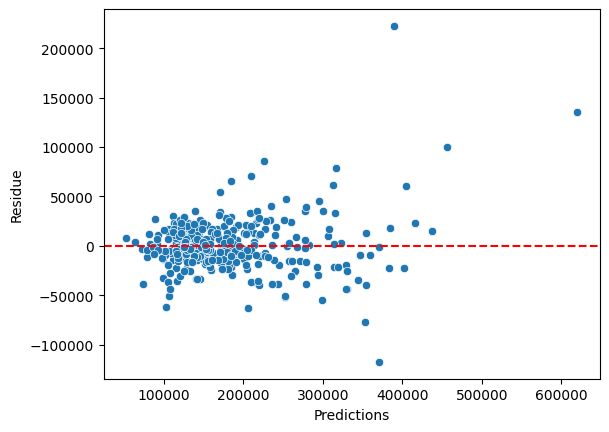

In [ ]:
residue = y_test-y_pred
 

plt.figure()
sns.scatterplot(x=y_pred,y=residue)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predictions")
plt.ylabel("Residue")
plt.show()

<Axes: ylabel='SalePrice'>

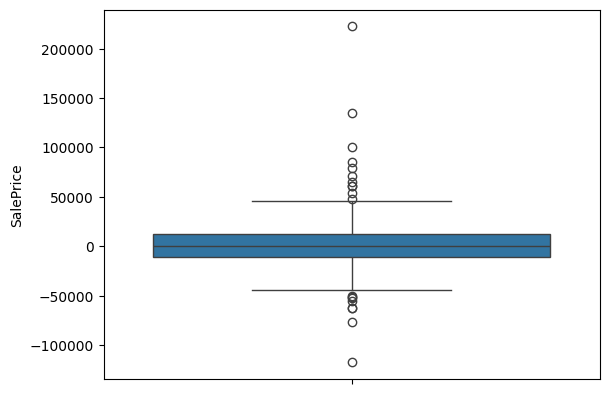

In [ ]:
sns.boxplot(residue)

# Observations: 

## Iteration 1: RMSE with Normalization + One Hot encoding: 39946.53
1. Outliers
2. Unbalanced Y Axis
3. Heteroskedasticity
Next Steps: Transforming the features

## Iteration 2: RMSE with Normalization + One Hot encoding + outlier handling: 35162.04 
After handling outliers the RMSE is reduced, although feature selection techniques should help further improve the model.

## Iteration 3: Feature Selection
1. After removing duplicate features there was no effect on the r2 score or RMSE
2. After applying correalation method for reducing feature the RMSE reduced to 34980 although the r2 score remains same
3. After applying variance threshold method still there's not change in evaluation parameters

## Iteration 4: Using Bagging ensemble technique 
1. After Bagging ensemble technique the r2 score improved to .90 while the cross val score improved to 79
2. The RMSE reduced to 26240.55

## Iteration 5: Using Voting Ensemble
1. After Using Linear Regression with Decision Tree Regressor and K Neighbour Regressor the r2 Score improved to .82
2. Although there was no change while experimenting with different weights of the tree models selected. 

## Iteration 6: Using Random Forest instead of decision trees
1. After using Random Forest Regressor the cross val r2 Score improved to .85, with added weights.